In [1]:
# Cellule 1 — Imports et chargement des données
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
print("=== Chargement des données ===\n")

with open('models/X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open('models/X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open('models/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('models/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)
with open('models/X_train_smote.pkl', 'rb') as f:
    X_train_smote = pickle.load(f)
with open('models/y_train_smote.pkl', 'rb') as f:
    y_train_smote = pickle.load(f)

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ X_train_smote : {X_train_smote.shape}")

=== Chargement des données ===

✅ X_train : (246008, 178)
✅ X_test  : (61503, 178)
✅ X_train_smote : (452296, 178)


In [2]:
# Cellule 2 — Score métier et modèle Baseline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier

# Fonction score métier
COUT_FN = 10
COUT_FP = 1

def score_metier(y_true, y_pred, cout_fn=COUT_FN, cout_fp=COUT_FP):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (cout_fn * fn) + (cout_fp * fp)

# Connexion MLFlow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("score_credit_experiment")

print("=== Modèle Baseline (DummyClassifier) ===\n")

with mlflow.start_run(run_name="baseline_dummy"):
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)

    auc = roc_auc_score(y_test, y_pred_dummy)
    score = score_metier(y_test, y_pred_dummy)

    mlflow.log_param("model", "DummyClassifier")
    mlflow.log_param("strategy", "most_frequent")
    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("score_metier", score)

    print(f"AUC-ROC      : {auc:.4f}")
    print(f"Score métier : {score}")
    print(f"\n{classification_report(y_test, y_pred_dummy)}")
    print("✅ Baseline loggée dans MLFlow !")

=== Modèle Baseline (DummyClassifier) ===

AUC-ROC      : 0.5000
Score métier : 49650

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503

✅ Baseline loggée dans MLFlow !
🏃 View run baseline_dummy at: http://127.0.0.1:5000/#/experiments/2/runs/b21bf7b1c9954d0aa8f02fa71fad575b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [5]:
# Cellule 3 — Logistic Regression (optimisé)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

print("=== Logistic Regression ===\n")

# Utiliser un échantillon pour aller plus vite
from sklearn.utils import resample
X_sample, y_sample = resample(
    X_train_smote, y_train_smote, 
    n_samples=50000, 
    random_state=42
)
print(f"Echantillon d'entraînement : {X_sample.shape}")

with mlflow.start_run(run_name="logistic_regression"):

    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=500, class_weight='balanced'))
    ])

    param_grid_lr = {
        'model__C': [0.1, 1],
        'model__solver': ['lbfgs']
    }

    grid_lr = GridSearchCV(
        pipeline_lr,
        param_grid_lr,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    print("Entraînement en cours...")
    grid_lr.fit(X_sample, y_sample)

    best_lr = grid_lr.best_estimator_
    y_pred_lr = best_lr.predict(X_test)
    y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

    auc_lr = roc_auc_score(y_test, y_proba_lr)
    score_lr = score_metier(y_test, y_pred_lr)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("best_C", grid_lr.best_params_['model__C'])
    mlflow.log_param("best_solver", grid_lr.best_params_['model__solver'])
    mlflow.log_metric("auc_roc", auc_lr)
    mlflow.log_metric("score_metier", score_lr)

    print(f"\n✅ Meilleurs params : {grid_lr.best_params_}")
    print(f"AUC-ROC      : {auc_lr:.4f}")
    print(f"Score métier : {score_lr}")
    print(f"\n{classification_report(y_test, y_pred_lr)}")
    print("✅ Logistic Regression loggée dans MLFlow !")

=== Logistic Regression ===

Echantillon d'entraînement : (50000, 178)
Entraînement en cours...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

✅ Meilleurs params : {'model__C': 1, 'model__solver': 'lbfgs'}
AUC-ROC      : 0.7154
Score métier : 48534

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.41      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.67      0.51      0.50     61503
weighted avg       0.88      0.92      0.88     61503

✅ Logistic Regression loggée dans MLFlow !
🏃 View run logistic_regression at: http://127.0.0.1:5000/#/experiments/2/runs/ddbbfe4294d84ce38997f61a62716f3a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [6]:
# Cellule 4 — Random Forest
from sklearn.ensemble import RandomForestClassifier

print("=== Random Forest ===\n")

X_sample_rf, y_sample_rf = resample(
    X_train_smote, y_train_smote,
    n_samples=50000,
    random_state=42
)

with mlflow.start_run(run_name="random_forest"):

    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20],
        'class_weight': ['balanced']
    }

    grid_rf = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid_rf,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    print("Entraînement en cours...")
    grid_rf.fit(X_sample_rf, y_sample_rf)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

    auc_rf = roc_auc_score(y_test, y_proba_rf)
    score_rf = score_metier(y_test, y_pred_rf)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("best_n_estimators", grid_rf.best_params_['n_estimators'])
    mlflow.log_param("best_max_depth", grid_rf.best_params_['max_depth'])
    mlflow.log_metric("auc_roc", auc_rf)
    mlflow.log_metric("score_metier", score_rf)

    print(f"\n✅ Meilleurs params : {grid_rf.best_params_}")
    print(f"AUC-ROC      : {auc_rf:.4f}")
    print(f"Score métier : {score_rf}")
    print(f"\n{classification_report(y_test, y_pred_rf)}")
    print("✅ Random Forest loggée dans MLFlow !")

=== Random Forest ===

Entraînement en cours...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Meilleurs params : {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 200}
AUC-ROC      : 0.6953
Score métier : 46864

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     56538
           1       0.23      0.08      0.12      4965

    accuracy                           0.90     61503
   macro avg       0.58      0.53      0.54     61503
weighted avg       0.87      0.90      0.88     61503

✅ Random Forest loggée dans MLFlow !
🏃 View run random_forest at: http://127.0.0.1:5000/#/experiments/2/runs/776ab8b030964fdba132607cb3d2ea68
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [7]:
# Cellule 5 — XGBoost
import xgboost as xgb

print("=== XGBoost ===\n")

X_sample_xgb, y_sample_xgb = resample(
    X_train_smote, y_train_smote,
    n_samples=100000,
    random_state=42
)
print(f"Echantillon d'entraînement : {X_sample_xgb.shape}")

with mlflow.start_run(run_name="xgboost"):

    param_grid_xgb = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'scale_pos_weight': [10]
    }

    grid_xgb = GridSearchCV(
        xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='auc'),
        param_grid_xgb,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )

    print("Entraînement en cours...")
    grid_xgb.fit(X_sample_xgb, y_sample_xgb)

    best_xgb = grid_xgb.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    score_xgb = score_metier(y_test, y_pred_xgb)

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("best_n_estimators", grid_xgb.best_params_['n_estimators'])
    mlflow.log_param("best_max_depth", grid_xgb.best_params_['max_depth'])
    mlflow.log_param("best_learning_rate", grid_xgb.best_params_['learning_rate'])
    mlflow.log_metric("auc_roc", auc_xgb)
    mlflow.log_metric("score_metier", score_xgb)

    print(f"\n✅ Meilleurs params : {grid_xgb.best_params_}")
    print(f"AUC-ROC      : {auc_xgb:.4f}")
    print(f"Score métier : {score_xgb}")
    print(f"\n{classification_report(y_test, y_pred_xgb)}")
    print("✅ XGBoost loggé dans MLFlow !")

=== XGBoost ===

Echantillon d'entraînement : (100000, 178)
Entraînement en cours...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Meilleurs params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 10}
AUC-ROC      : 0.7294
Score métier : 35289

              precision    recall  f1-score   support

           0       0.95      0.77      0.85     56538
           1       0.17      0.55      0.26      4965

    accuracy                           0.75     61503
   macro avg       0.56      0.66      0.56     61503
weighted avg       0.89      0.75      0.80     61503

✅ XGBoost loggé dans MLFlow !
🏃 View run xgboost at: http://127.0.0.1:5000/#/experiments/2/runs/b1481a0d569541dba206023a3b54e839
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


=== Comparaison des modèles ===



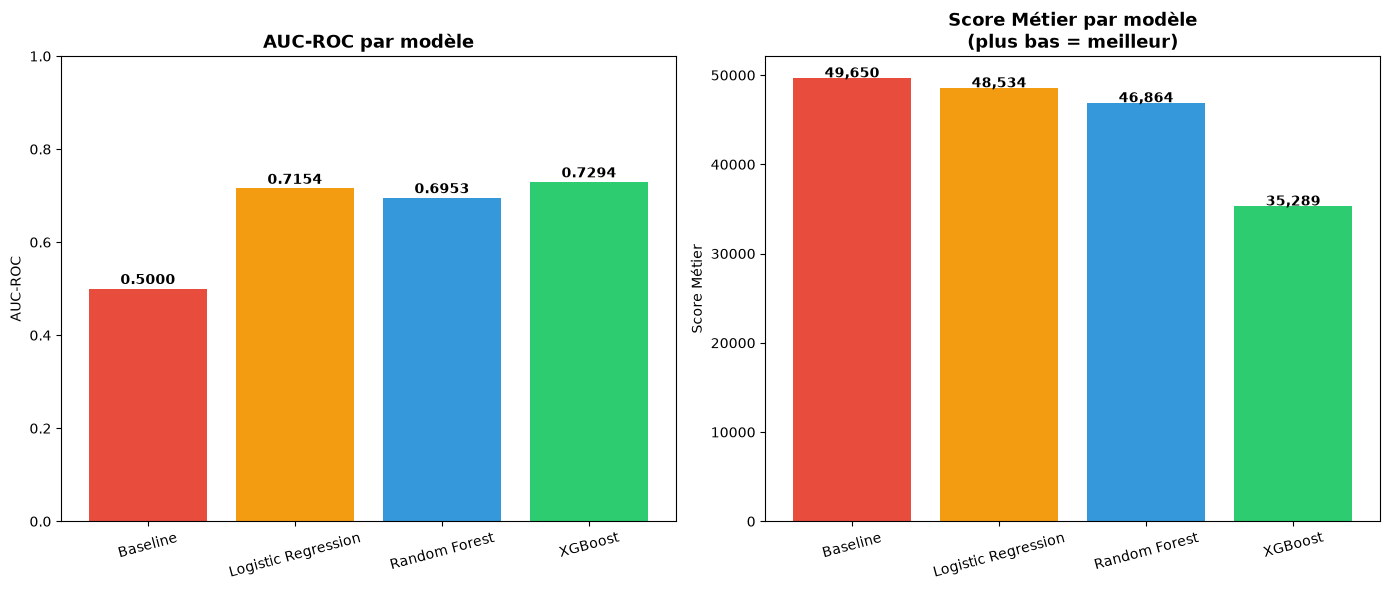

✅ XGBoost est le meilleur modèle !


In [8]:
# Cellule 6 — Comparaison visuelle des modèles
print("=== Comparaison des modèles ===\n")

modeles = ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']
aucs = [0.5000, 0.7154, 0.6953, 0.7294]
scores = [49650, 48534, 46864, 35289]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AUC-ROC
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars1 = axes[0].bar(modeles, aucs, color=colors)
axes[0].set_title('AUC-ROC par modèle', fontsize=13, fontweight='bold')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Score Métier
bars2 = axes[1].bar(modeles, scores, color=colors)
axes[1].set_title('Score Métier par modèle\n(plus bas = meilleur)', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score Métier')
for bar, val in zip(bars2, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("✅ XGBoost est le meilleur modèle !")

=== Analyse SHAP — Explicabilité XGBoost ===

✅ SHAP values calculées !


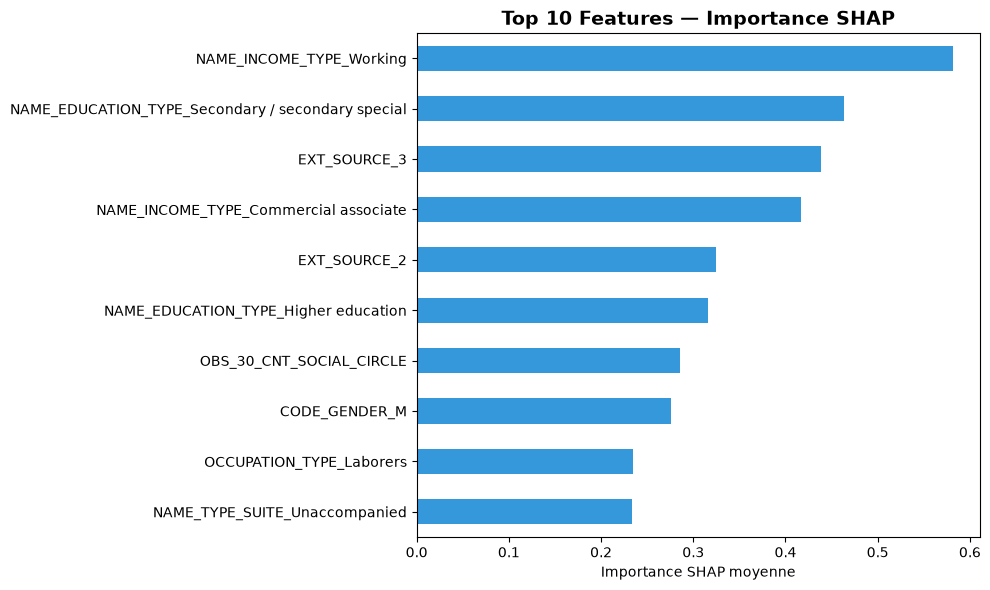

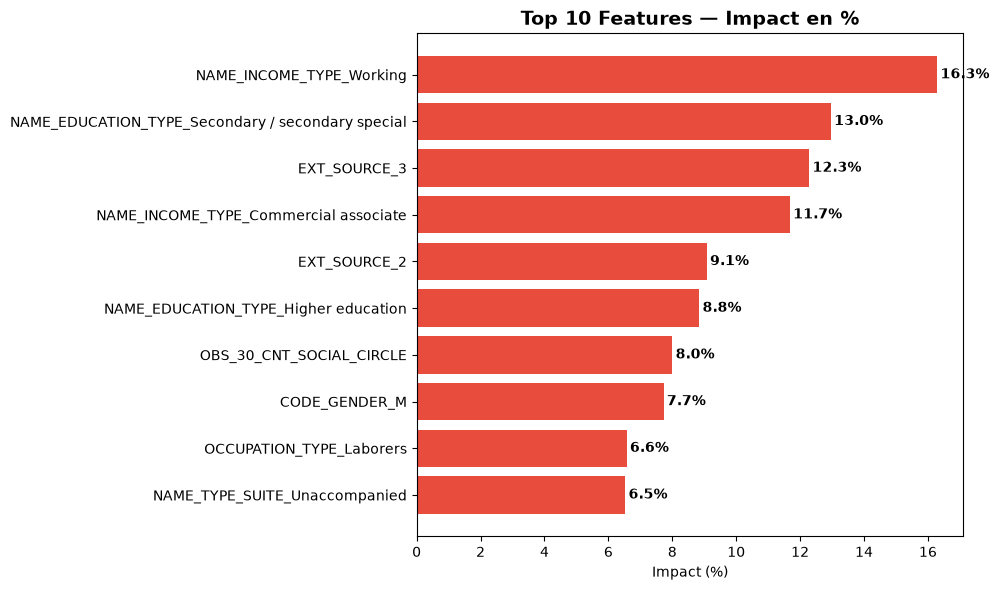


=== Tableau SHAP — Top 10 Features ===

                                                Feature  Importance SHAP  Impact (%)
Rang                                                                                
1                              NAME_INCOME_TYPE_Working           0.5819   16.290001
2     NAME_EDUCATION_TYPE_Secondary / secondary special           0.4630   12.970000
3                                          EXT_SOURCE_3           0.4388   12.290000
4                 NAME_INCOME_TYPE_Commercial associate           0.4172   11.680000
5                                          EXT_SOURCE_2           0.3243    9.080000
6                  NAME_EDUCATION_TYPE_Higher education           0.3159    8.850000
7                              OBS_30_CNT_SOCIAL_CIRCLE           0.2859    8.000000
8                                         CODE_GENDER_M           0.2761    7.730000
9                              OCCUPATION_TYPE_Laborers           0.2348    6.580000
10                      

In [10]:
# Cellule 7 — SHAP (Explicabilité) — 3 visualisations
import shap
import pandas as pd
print("=== Analyse SHAP — Explicabilité XGBoost ===\n")

explainer = shap.TreeExplainer(best_xgb)
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)
print("✅ SHAP values calculées !")

# --- Visualisation 1 : Barres horizontales simples ---
mean_shap = pd.Series(
    abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
mean_shap.plot(kind='barh', color='#3498db')
plt.title('Top 10 Features — Importance SHAP', fontsize=14, fontweight='bold')
plt.xlabel('Importance SHAP moyenne')
plt.tight_layout()
plt.show()

# --- Visualisation 2 : Impact en % ---
total = mean_shap.sum()
mean_shap_pct = (mean_shap / total * 100).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(mean_shap_pct.index, mean_shap_pct.values, color='#e74c3c')
plt.title('Top 10 Features — Impact en %', fontsize=14, fontweight='bold')
plt.xlabel('Impact (%)')
for bar, val in zip(bars, mean_shap_pct.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Visualisation 3 : Tableau ---
shap_df = pd.DataFrame({
    'Feature': mean_shap.index[::-1],
    'Importance SHAP': mean_shap.values[::-1].round(4),
    'Impact (%)': (mean_shap.values[::-1] / total * 100).round(2)
})
shap_df.index = range(1, len(shap_df) + 1)
shap_df.index.name = 'Rang'
print("\n=== Tableau SHAP — Top 10 Features ===\n")
print(shap_df.to_string())
print("\n✅ Analyse SHAP terminée !")